# Statistical Pattern Recognition - Solution 2: Parametric distributions

In [145]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib import markers


## $\star$ Part 1: Pen and Paper exercise

Verify the ML estimator for the Bernoulli distribution given in the lecture slides.

## $\star$ Part 2: ML estimation

Estimate the mean and covariance matrix of the dataset *gaussian.npz* via ML
estimation.

Plot the points and indicate the mean via a cross and the covariance via an
ellipse. 

Consult the matplotlib documentation to see how to draw an ellipse. 
(https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.patches.Ellipse.html)


You obtain the ellipse axes by an eigen-decomposition of the matrix (Numpy function linalg.eig). 

The scaling of the axes is given by the eigenvalues.
Review the concept of an eigen-decomposition in the
internet or a math book if you lack this basic math knowledge.

### Part 2.1: Mean and Covariance estimation

Estimate the mean and covariance matrix of the dataset, you can compare these to the built in numpy functions and see if you see a difference.


In [146]:
# Load the data
from pathlib import Path
from matplotlib.patches import Ellipse
data_dir = Path('../data')

gaussian = np.load(data_dir / "gaussian.npz")['arr_0']
print(gaussian.shape)

# Manual Mean
manual_mean = [0.0, 0.0]
for i in range(gaussian.shape[0]):
    manual_mean[0] = manual_mean[0]+gaussian[i][0]
    manual_mean[1] = manual_mean[1]+gaussian[i][1]
manual_mean = np.divide(manual_mean, 100)
print(f'Manual mean of X : {manual_mean[0]}')
print(f'Manual mean of y : {manual_mean[1]}')

# Numpy Mean
np_mean = np.empty((1, 2))
np_mean[0][0] = np.mean(gaussian[:,0], axis=0)
np_mean[0][1] = np.mean(gaussian[:,1], axis=0)
print(f'Numpy Mean of X : {np_mean[0][0]}')
print(f'Numpy Mean of y : {np_mean[0][1]}')

(100, 2)
Manual mean of X : 2.1230853375010064
Manual mean of y : 3.121684016991558
Numpy Mean of X : 2.1230853375010055
Numpy Mean of y : 3.121684016991558


In [147]:
# Estimate the covariance and compare your result with numpy's built-in function

# Manual Covariance
cov_matrix = [[0.0, 0.0], [0.0, 0.0]]
for i in range(gaussian.shape[1]):
    for j in range(gaussian.shape[1]):
        cov_matrix[i][j] = np.divide(np.sum([(gaussian[k][i]-manual_mean[i])*(gaussian[k][j]-manual_mean[j]) for k in range(gaussian.shape[0])]), gaussian.shape[0])
print(f'Cov Matrix : {np.array(cov_matrix)}')

# Numpy Covariance
np_cov_matrix = np.cov(gaussian, rowvar=False)
print(f'Cov Matrix : {np_cov_matrix}')


Cov Matrix : [[1.33765954 2.0820358 ]
 [2.0820358  3.98639368]]
Cov Matrix : [[1.35117126 2.10306646]
 [2.10306646 4.02666029]]


### Part 2.2: Plotting the graph

Plot the points and indicate the mean via a cross and the covariance via an ellipse.


Eigen vals : [0.1964373  5.18139424]
Eigen vectors : [[-0.87655934 -0.48129379]
 [ 0.48129379 -0.87655934]]


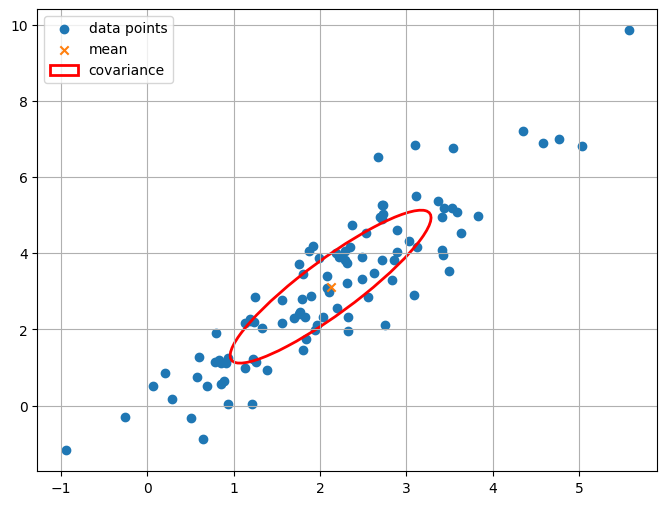

In [148]:
# Ellipse construction
eigen_val, eigen_vec = np.linalg.eig(np_cov_matrix)
print(f'Eigen vals : {eigen_val}')
print(f'Eigen vectors : {eigen_vec}')
angle = np.degrees(np.arctan2(*eigen_vec[:, 0][::-1]))
width, height = 2 * np.sqrt(eigen_val)
ellipse = Ellipse(xy=(np_mean[0][0], np_mean[0][1]), width=width, height=height, angle=angle, edgecolor='r', facecolor='none', linewidth=2, label="covariance")

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(gaussian[:, 0], gaussian[:, 1], label="data points")
plt.scatter(np_mean[0][0], np_mean[0][1], marker="x", label="mean")
ax = plt.gca()
ax.add_patch(ellipse)
plt.grid()
plt.legend()
plt.show()

## $\star\star$ Part 3: MAP estimation

Create reduced datasets by considering only the first 2, 5, 10 points and estimate the mean via MAP. 

Use the ML estimate of the covariance $ \Sigma $ <sub>**ML,100**</sub> (estimated from all 100 points) as known covariance. 

Assume the conjugate prior with $\mu_0 = (2,3)^T $ and covariance $\Sigma_0 =\Sigma $ <sub>**ML,100**</sub>


Draw the ML and the MAP estimates into the point clouds (the covariance is the same as it is assumed to be known here). 

How reliable is the ML estimate when there are only few measurements? 

Now work with a slightly wrong prior $\mu_0 = (2,5)^T $
and see how the effect of the prior is reduced as more measurements come in.


### Part 3.1: Using the correct prior

Using   $\mu_0 = (2,3)^T $

For the formulae for the multivariate Gaussian MAP estimate given mean prior, covariance prior and true covariance see:

[0] [https://www.cs.ubc.ca/~murphyk/Papers/bayesGauss.pdf](https://www.cs.ubc.ca/~murphyk/Papers/bayesGauss.pdf) page 17 equation (211)

[1] [https://www.cs.ubc.ca/~murphyk/Papers/bayesGauss.pdf](https://www.cs.ubc.ca/~murphyk/Papers/bayesGauss.pdf) Page 17 equation(212)

For details see Christopher M. Bishop, Pattern Recognition and Machine Learning, p. 92.


In [149]:
# Estimate the ML and MAP mean

mean_prior = np.array([[2.0], [3.0]])
cov_prior = np_cov_matrix
true_cov = cov_prior
N = [2, 5, 10]

cov_prior_inv = np.linalg.inv(cov_prior)
true_cov_inv = np.linalg.inv(true_cov)

map_mean = [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
for i in range(len(N)):
    map_cov = np.linalg.inv(cov_prior_inv + N[i] * true_cov_inv)
    map_mean[i] = np.matmul(map_cov, (N[i] * np.matmul(true_cov_inv, np_mean.T) + np.matmul(cov_prior_inv, mean_prior)))

    print(f'N = {i}')
    print(f'MAP Covariance : {map_cov}')
    print('############################')

map_mean = np.array(map_mean)
print(f'MAP Mean : {map_mean}')
print(f'{map_mean.shape}')

N = 0
MAP Covariance : [[0.45039042 0.70102215]
 [0.70102215 1.3422201 ]]
############################
N = 1
MAP Covariance : [[0.22519521 0.35051108]
 [0.35051108 0.67111005]]
############################
N = 2
MAP Covariance : [[0.12283375 0.19118786]
 [0.19118786 0.36606003]]
############################
MAP Mean : [[[2.08205689]
  [3.08112268]]

 [[2.10257111]
  [3.10140335]]

 [[2.11189576]
  [3.11062183]]]
(3, 2, 1)


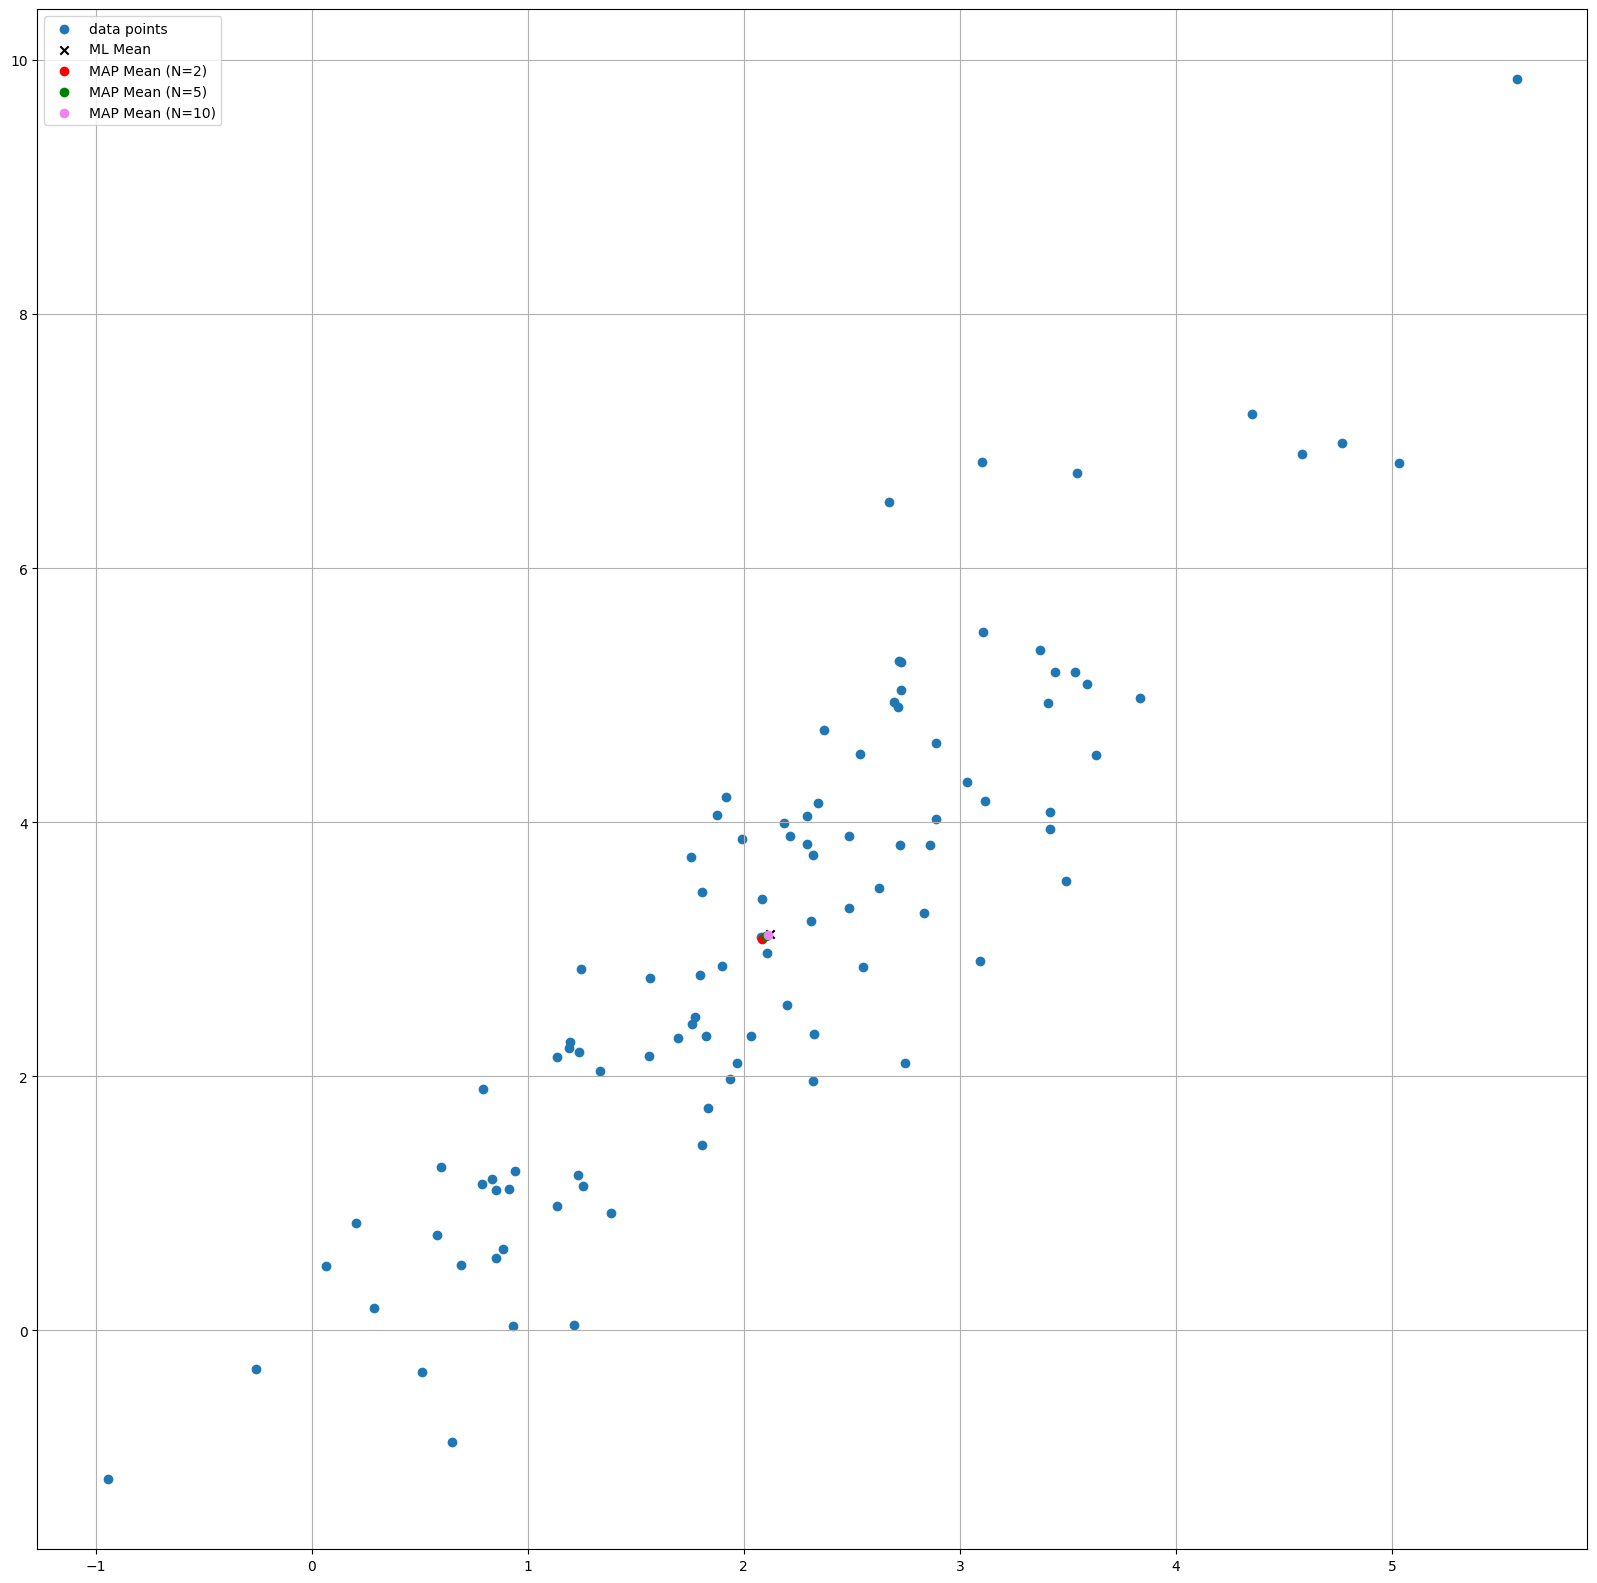

In [150]:
# Plot the datapoints and the ML and MAP mean estimates for different numbers of samples

# Plotting
plt.figure(figsize=(20, 20))
plt.scatter(gaussian[:, 0], gaussian[:, 1], label="data points")
plt.scatter(np_mean[0][0], np_mean[0][1], marker="x", label="ML Mean", color="black")

plt.scatter(map_mean[0][0][0], map_mean[0][1][0], marker="o", label="MAP Mean (N=2)", color="red")
plt.scatter(map_mean[1][0][0], map_mean[1][1][0], marker="o", label="MAP Mean (N=5)", color="green")
plt.scatter(map_mean[2][0][0], map_mean[2][1][0], marker="o", label="MAP Mean (N=10)", color="violet")

plt.grid()
plt.legend()
plt.show()


### Part 3.2: Using a slightly wrong prior

Using $\mu_0 = (2,5)^T $


In [ ]:
mean_prior = np.array([[2.0], [5.0]])

map_mean = [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
for i in range(len(N)):

    map_cov = np.linalg.inv(cov_prior_inv + N[i] * true_cov_inv)
    map_mean[i] = np.matmul(map_cov, (N[i] * np.matmul(true_cov_inv, np_mean.T) + np.matmul(cov_prior_inv, mean_prior)))

    print(f'N = {i}')
    print(f'MAP Covariance : {map_cov}')
    print('############################')

map_mean = np.array(map_mean)
print(f'MAP Mean : {map_mean}')

N = 0
MAP Covariance : [[0.45039042 0.70102215]
 [0.70102215 1.3422201 ]]
############################
N = 1
MAP Covariance : [[0.22519521 0.35051108]
 [0.35051108 0.67111005]]
############################
N = 2
MAP Covariance : [[0.12283375 0.19118786]
 [0.19118786 0.36606003]]
############################
MAP Mean : [[[2.08205689]
  [3.74778934]]

 [[2.10257111]
  [3.43473668]]

 [[2.11189576]
  [3.29244002]]]
(3, 2, 1)


## $\star$ Part 4: Gaussianplus

Estimate mean and covariance of the dataset *gaussianplus.npz* using ML and show the result.
How well does the estimate reflect the true data?


In [152]:
# START TODO #################
raise NotImplementedError
# END TODO #################


NotImplementedError: 